# Download Audio MNIST Dataset

Downloads the [Audio MNIST](https://huggingface.co/datasets/gilkeyio/AudioMNIST) dataset from Hugging Face and saves metadata to `data/processed/`.

In [1]:
from pathlib import Path
from datasets import load_dataset, Audio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = Path("..").resolve()
DATA_DIR = PROJECT_DIR / "data" / "processed"
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
ds = load_dataset("gilkeyio/AudioMNIST")
ds = ds.cast_column("audio", Audio(decode=False))

print(f"Train: {len(ds['train'])} samples")
print(f"Test:  {len(ds['test'])} samples")
print(f"Columns: {ds['train'].column_names}")

Train: 24000 samples
Test:  6000 samples
Columns: ['speaker_id', 'audio', 'digit', 'gender', 'accent', 'age', 'native_speaker', 'origin']


In [3]:
records = [{
    "digit": s["digit"],
    "speaker_id": s["speaker_id"],
    "gender": "male" if s["gender"] == 0 else "female",
    "accent": s["accent"],
    "age": s["age"],
    "origin": s["origin"],
    "split": split_name,
} for split_name, split in ds.items() for s in split]

df = pd.DataFrame(records)
df.to_csv(DATA_DIR / "audio_mnist_metadata.csv", index=False)
print(f"Saved: {DATA_DIR / 'audio_mnist_metadata.csv'}")
print(f"Total: {len(df)} records")
df.head()

Saved: C:\Users\Teva\Desktop\Repertoire trié\Cours\Erasmus\Practice1\SDOML-project1\data\processed\audio_mnist_metadata.csv
Total: 30000 records


,digit,speaker_id,gender,accent,age,origin,split
0,7,59,female,German,31.0,"Europe, Germany, Berlin",train
1,7,59,female,German,31.0,"Europe, Germany, Berlin",train
2,2,59,female,German,31.0,"Europe, Germany, Berlin",train
3,3,59,female,German,31.0,"Europe, Germany, Berlin",train
4,9,59,female,German,31.0,"Europe, Germany, Berlin",train


### AUDIO MNIST ANALYSIS
Plot the class balance relation, metadata information of the speakers and train/validation split

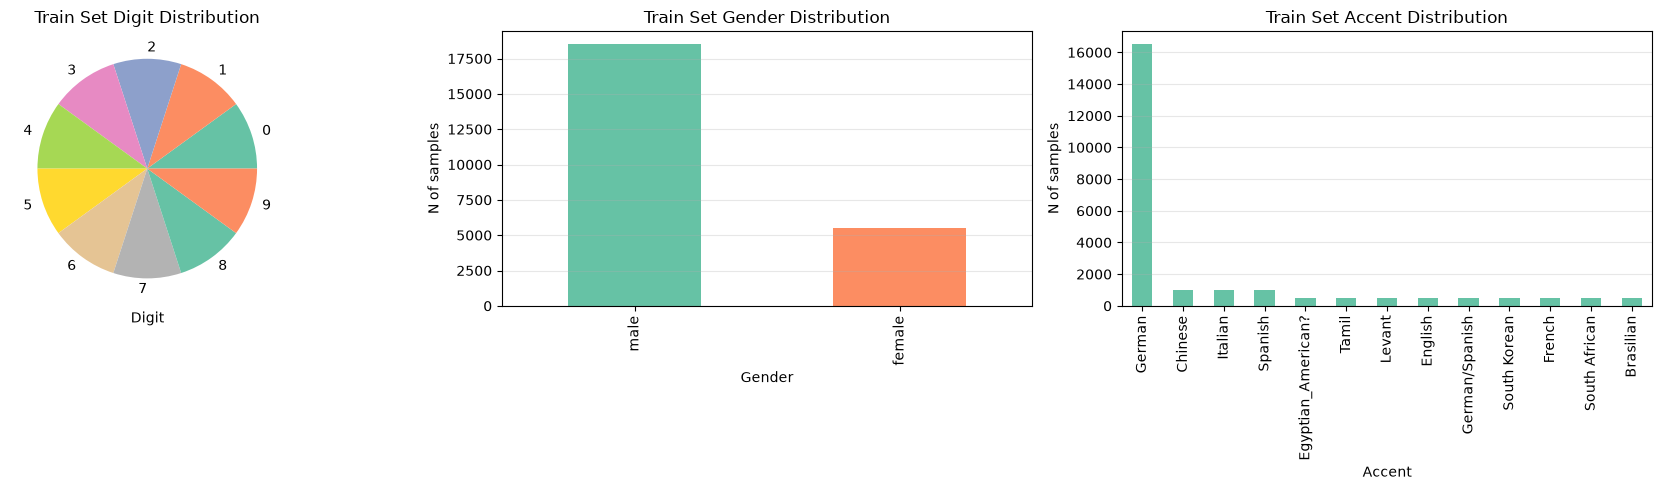

In [4]:
palette = sns.color_palette("Set2", n_colors=10)
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "test"]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Train Digit distribution
digit_counts = train_df["digit"].value_counts().sort_index()
digit_counts.plot.pie(ax=axs[0], colors=palette[:len(digit_counts)])
axs[0].set_title("Train Set Digit Distribution")
axs[0].set_xlabel("Digit")

# Train Gender distribution
train_df["gender"].value_counts().plot.bar(ax=axs[1], color=palette[:2])
axs[1].set_title("Train Set Gender Distribution")
axs[1].set_xlabel("Gender")
axs[1].set_ylabel("N of samples")
axs[1].grid(axis="y", alpha=0.3)

# Train Accent distribution
train_df["accent"].value_counts().plot.bar(ax=axs[2], color=palette[:1])
axs[2].set_title("Train Set Accent Distribution")
axs[2].set_xlabel("Accent")
axs[2].set_ylabel("N of samples")
axs[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

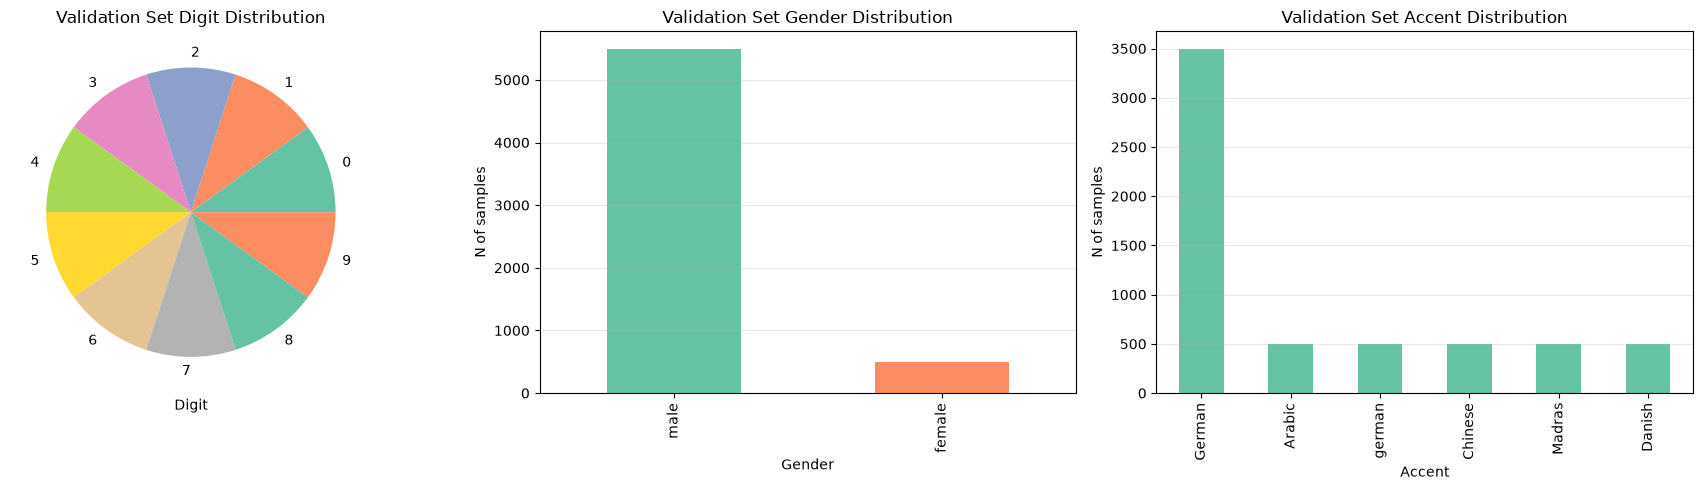

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Validation Digit distribution
digit_counts = valid_df["digit"].value_counts().sort_index()
digit_counts.plot.pie(ax=axs[0], colors=palette[:len(digit_counts)])
axs[0].set_title("Validation Set Digit Distribution")
axs[0].set_xlabel("Digit")

# Validation Gender distribution
valid_df["gender"].value_counts().plot.bar(ax=axs[1], color=palette[:2])
axs[1].set_title("Validation Set Gender Distribution")
axs[1].set_xlabel("Gender")
axs[1].set_ylabel("N of samples")
axs[1].grid(axis="y", alpha=0.3)

# Validation Accent distribution
valid_df["accent"].value_counts().plot.bar(ax=axs[2], color=palette[:1])
axs[2].set_title("Validation Set Accent Distribution")
axs[2].set_xlabel("Accent")
axs[2].set_ylabel("N of samples")
axs[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

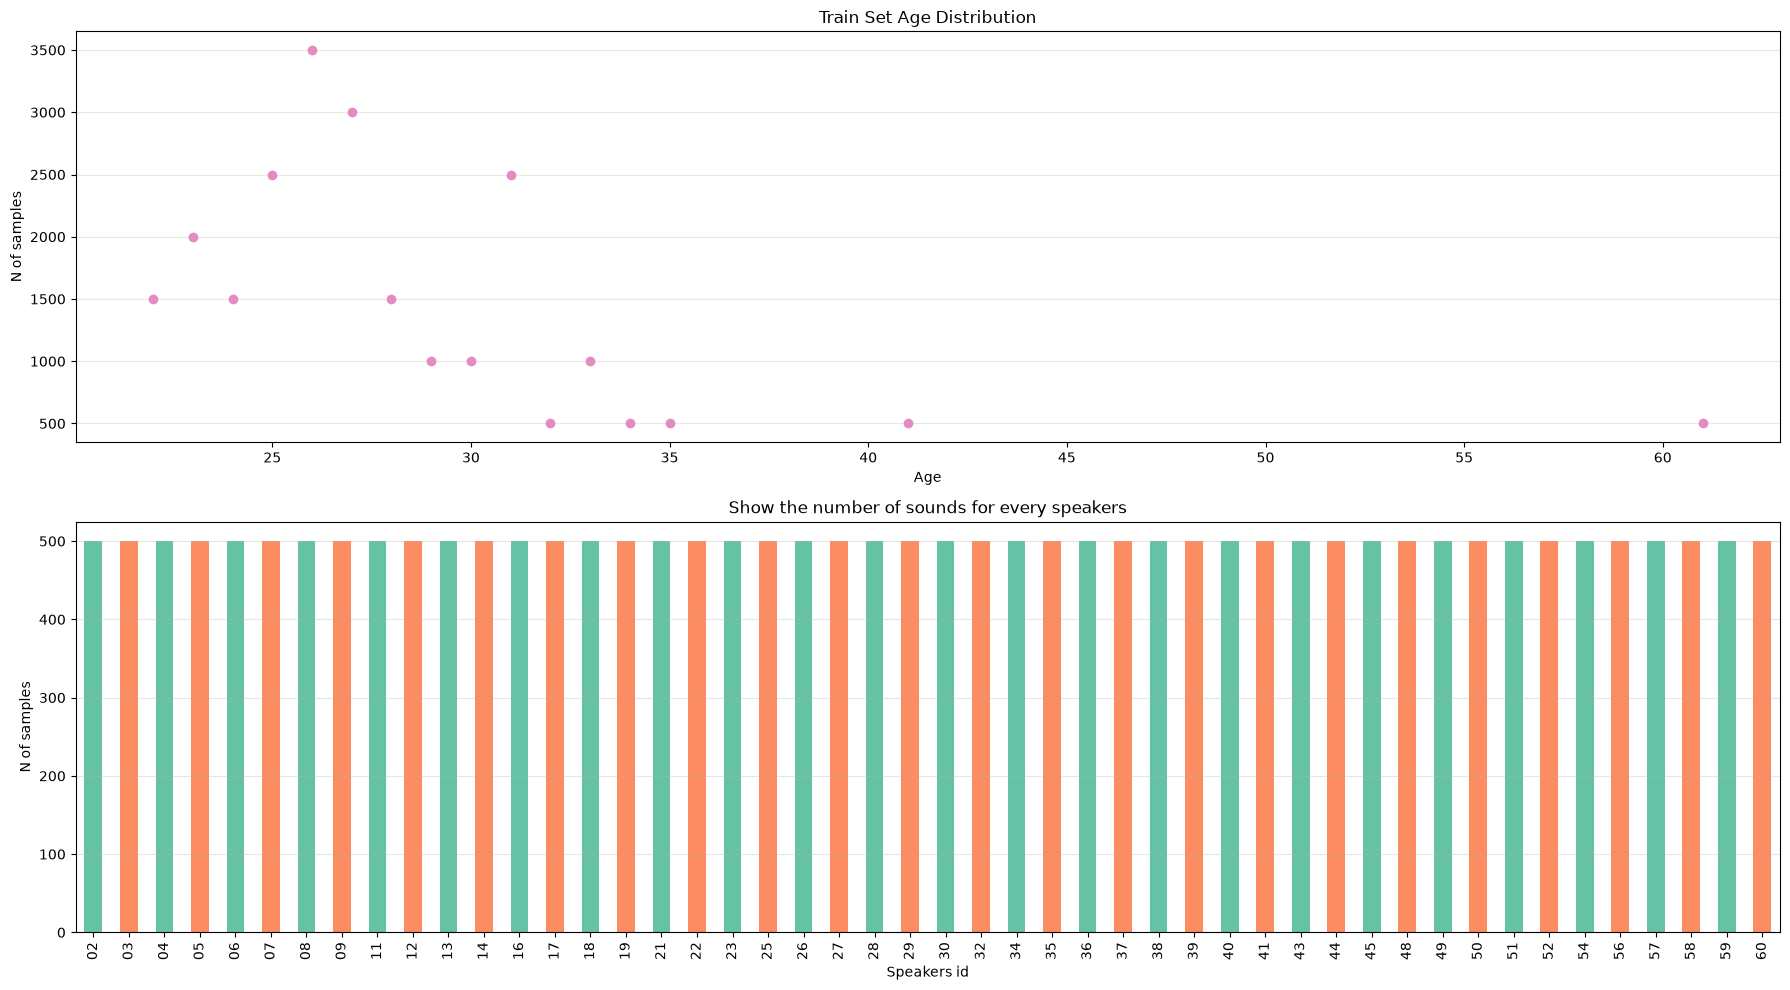

Here note that there is 48 speakers, the others are in the test sample


In [6]:
fig, axs = plt.subplots(2, 1, figsize=(18, 10))

# Number of sound for each ages
age_counts = train_df["age"].value_counts().sort_index()
axs[0].scatter(age_counts.index, age_counts.values, color=palette[3])
axs[0].set_title("Train Set Age Distribution")
axs[0].set_xlabel("Age")
axs[0].set_ylabel("N of samples")
axs[0].grid(axis="y", alpha=0.3)

# Train Set Number of sound for each speakers
train_df["speaker_id"].value_counts().sort_index().plot.bar(ax=axs[1], color=palette[:2])
axs[1].set_title("Show the number of sounds for every speakers")
axs[1].set_xlabel("Speakers id")
axs[1].set_ylabel("N of samples")
axs[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Here note that there is {train_df['speaker_id'].nunique()} speakers, the others are in the test sample")

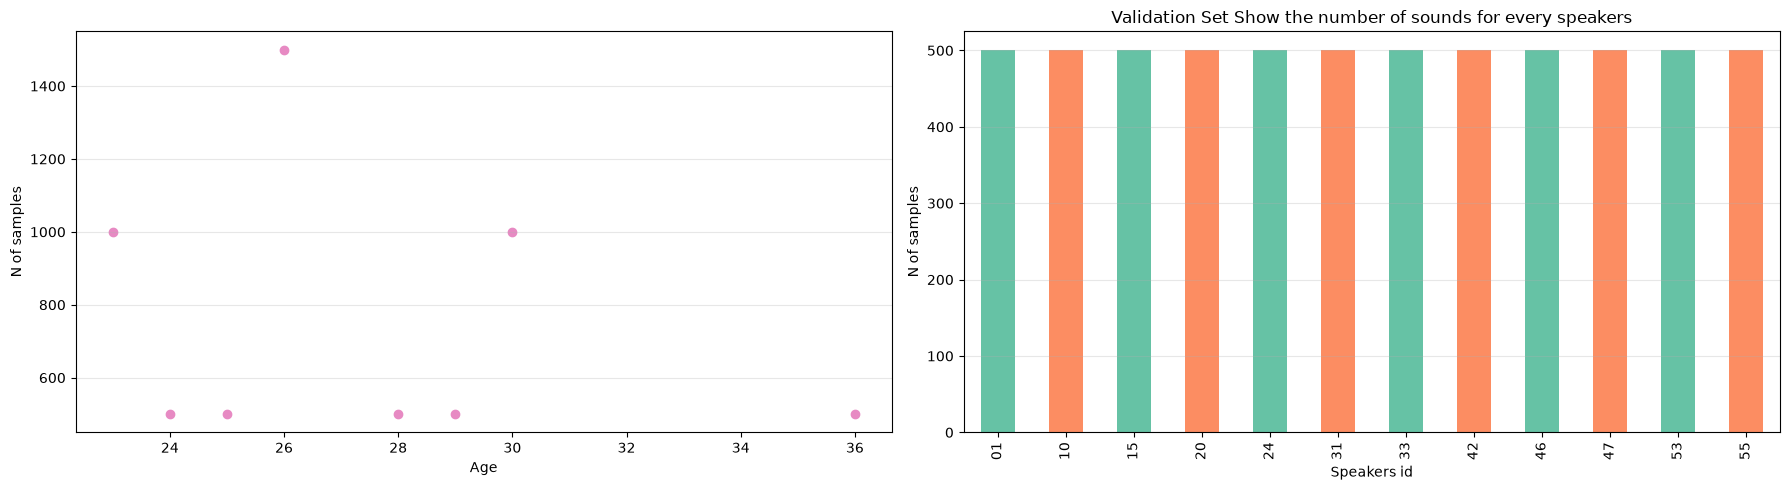

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

# Validation of sound for each ages
age_counts = valid_df["age"].value_counts().sort_index()
axs[0].scatter(age_counts.index, age_counts.values, color=palette[3])
axs[0].set_xlabel("Age")
axs[0].set_ylabel("N of samples")
axs[0].grid(axis="y", alpha=0.3)

# Validation Set Number of sound for each speakers
valid_df["speaker_id"].value_counts().sort_index().plot.bar(ax=axs[1], color=palette[:2])
axs[1].set_title("Validation Set Show the number of sounds for every speakers")
axs[1].set_xlabel("Speakers id")
axs[1].set_ylabel("N of samples")
axs[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

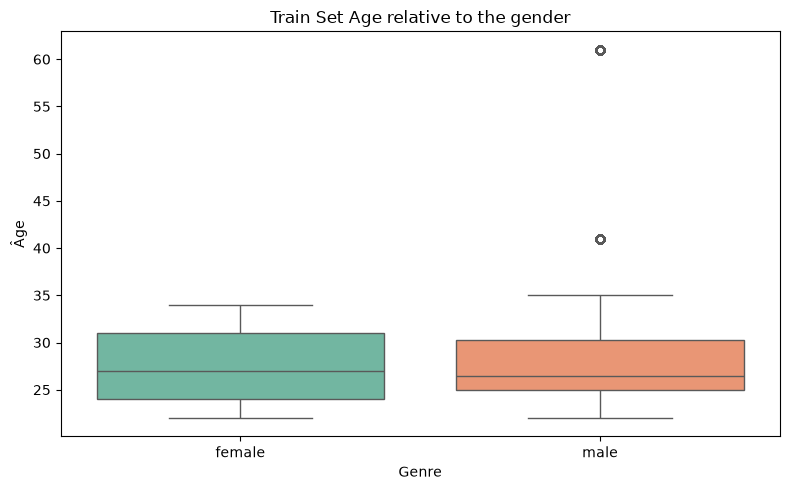

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=train_df, x="gender", y="age", hue="gender", palette="Set2", legend=False, ax=ax)

ax.set_title("Train Set Age relative to the gender")
ax.set_xlabel("Genre")
ax.set_ylabel("Âge")

plt.tight_layout()
plt.show()

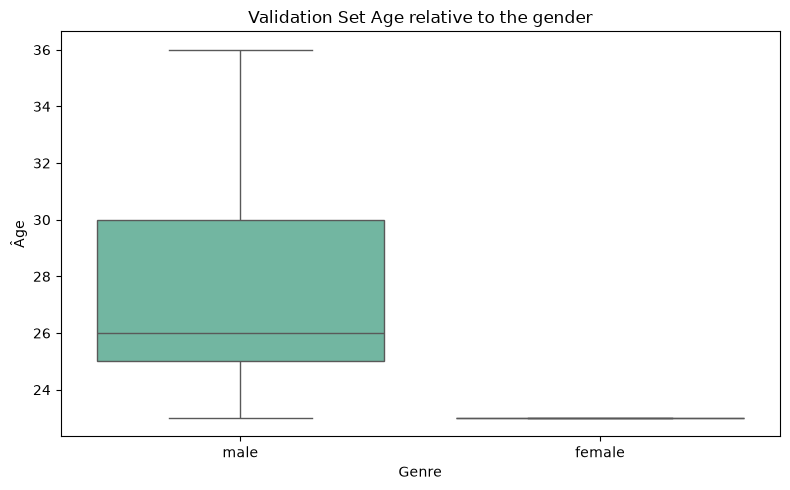

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=valid_df, x="gender", y="age", hue="gender", palette="Set2", legend=False, ax=ax)

ax.set_title("Validation Set Age relative to the gender")
ax.set_xlabel("Genre")
ax.set_ylabel("Âge")

plt.tight_layout()
plt.show()

In [10]:
print("Here we transform the signal in vector of 26 digit and build the dataset and then we reused the pythorch exemple of the course and adapt it so it works with the dataset (unit 2.2 slide 9)")

Here we transform the signal in vector of 26 digit and build the dataset and then we reused the pythorch exemple of the course and adapt it so it works with the dataset (unit 2.2 slide 9)


In [11]:
import librosa
from tqdm import tqdm
import soundfile as sf
import io
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [12]:
N_MFCC = 13

def extract_features(audio_array, sample_rate):
    """To transform audio signal in vector"""
    mfcc = librosa.feature.mfcc(y=audio_array.astype(np.float32), sr=sample_rate, n_mfcc=N_MFCC)
    mean = mfcc.mean(axis=1)
    std = mfcc.std(axis=1)
    return np.concatenate([mean, std])

In [13]:
def decode_audio(example):
    """Décode un exemple audio HuggingFace (bytes ou path) sans passer par torchcodec."""
    audio_field = example["audio"]
    if audio_field["bytes"] is not None:
        data, sample_rate = sf.read(io.BytesIO(audio_field["bytes"]))
    else:
        data, sample_rate = sf.read(audio_field["path"])
    return data, sample_rate

ds = ds.cast_column("audio", Audio(decode=False))

def build_feature_dataset(hf_split):
    X, y = [], []
    for s in tqdm(hf_split, desc="Extract features"):
        audio_array, sr = decode_audio(s)
        features = extract_features(audio_array, sr)
        X.append(features)
        y.append(s["digit"])
    return np.array(X), np.array(y)

X_train, y_train = build_feature_dataset(ds["train"])
X_test, y_test = build_feature_dataset(ds["test"])

print(X_train.shape, y_train.shape)  # ex: (24000, 26) (24000,)

Extract features: 100%|██████████| 6000/6000 [00:15<00:00, 381.13it/s]

(24000, 26) (24000,)


In [14]:
class AudioMNISTFeaturesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AudioMNISTFeaturesDataset(X_train, y_train)
test_dataset = AudioMNISTFeaturesDataset(X_test, y_test)

# Data loaders
loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [15]:
# Model
class Net(nn.Module):
  def __init__(self, input_dim=26, num_classes=10):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 64) #transform 26 numbers in 64 others (trying to find paterns)
    self.fc2 = nn.Linear(64, 32) # reduce numbers by 2
    self.fc3 = nn.Linear(32, num_classes) # transform in 10 numbers because 0 to 9
  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    return self.fc3(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = Net(input_dim=X_train.shape[1]).to(device)
opt = optim.Adam(net.parameters())
loss_fn = nn.CrossEntropyLoss()

# Training
for epoch in range(10):
  for xb, yb in loader:
    xb, yb = xb.to(device), yb.to(device)
    opt.zero_grad()
    out = net(xb)
    loss = loss_fn(out, yb)
    loss.backward()
    opt.step()

# Evaluation
net.eval()
correct = 0
total = 0
with torch.no_grad():
  for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    out = net(xb)
    preds = out.argmax(1)
    correct += (preds == yb).sum().item()
    total += yb.size(0)
      
accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9085
